In [1]:
# Python implementation of nonlocal graphene simulation
import numpy as np
from scipy.linalg import norm, solve, toeplitz
from scipy.fft import fft, ifft, fftfreq
from math import floor
import matplotlib.pyplot as plt
from time import time
import warnings
warnings.filterwarnings('ignore')
defaultDPI = 300 # 1200

In [2]:
# Physical Parameters
T = 'M' # Choice of polarization, 'E' for transverse electric, 'M' for magnetic.
D = [1,2,4,8] # Lateral period (mum)
Aloc, Anloc = {}, {}
for d in D:
    Aloc[d], Anloc[d] = [], [] # Absorbance for each period
N = [0,1] # Normal vector
EF = 0.4 # Fermi level position (eV)
vF = 1 # Fermi velocity (mum/s)
tau = 0.09 # Carrier lifetime (s)

# Numerical Parameters
Nf = 128 # Frequency precision
delta = 1 # Perturbation parameter
F = np.linspace(1,13,Nf) # Incident linear frequency (THz)

# Physical Constants
Tc = 2.9979e2 # Speed of light (Tmum/s)
hT = 4.1357e-3 # Planck’s constant (eV/THz)
hBarT = 6.5821e-4 # Dirac constant hBar = h/(2pi)
hc = 1.2398 # Precomputed h*c
Gamma = 3.7e-3 # hBar * relaxation rate (eV)
e2epsilon0 = 55.2635 # Vacuum permittivity (e^2/eV/mum)

In [3]:
# padesum - Sums a truncated Taylor series via Pade approximation. Adopted from David Nicholls
# Inputs:
# c - Taylor series coefficients: [c_0,...,c_N]
# Eps - Value at which to sum
# M - Numerator and denominator degree (M = N/2)
# Output: Pade approximant evaluated at Eps
def padesum(c,Eps,M):
    c = np.array(c)
    if M==0:
        a = np.array([c[0]]); b = np.array([1])
    else:
        H = toeplitz(c[M:2*M], c[M::-1][:M])
        bb = -solve(H, c[M+1:2*M+1])
        b = np.concatenate([np.array([1]),bb])
        aa = np.convolve(b, c[0:M+1])
        a = aa[0:M+1]
    return np.polyval(a[::-1], Eps) / np.polyval(b[::-1], Eps)

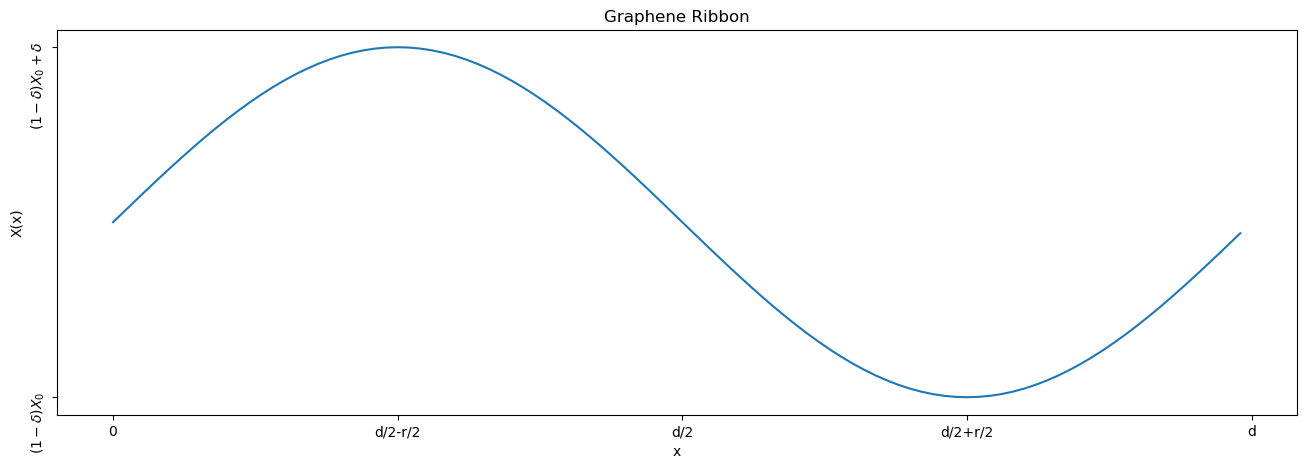

In [4]:
# Graphene Ribbon Envelope Function Shape
ribbon = 'sine'
X0 = 1
d = D[3]; w = d/2; x = np.linspace(0,d,100,endpoint=False)
if ribbon == 'nsmooth':
    X = lambda x: X0+delta*(-X0+np.sqrt(1-4*((x-d/2)/w)**2)) if (d/2-w/2<x and x<d/2+w/2) else (1-delta)*X0
elif ribbon == 'sine':
    X = lambda x: (1-delta)*X0+delta*(1+np.sin(x/d*2*np.pi))/2
plt.figure(figsize=(16,5))
plt.plot(x, list(map(X,x)))
plt.xlabel('x'); plt.xticks([0,2,4,6,8],['0','d/2-r/2','d/2','d/2+r/2','d'])
plt.ylabel('X(x)'); plt.yticks([0,1],[r'$(1-\delta)X_0$',r'$(1-\delta)X_0+\delta$'],rotation=90)
plt.title('Graphene Ribbon')
plt.savefig('image/ribbon_{}.png'.format(ribbon), dpi=defaultDPI, bbox_inches='tight')
plt.show()

In [5]:
def HOPE(epsilon_u, epsilon_w, envelope, d, theta, f, Nx, L, sum):
    I = np.eye(Nx) # Identity matrix
    P = fftfreq(Nx)*Nx # Fourier wavenumber = sample frequencies * signal size
    x = np.linspace(0,d,Nx,endpoint=False) # x=d omitted for periodicity
    tau_u = (T=='E') + (T=='M')/epsilon_u; tau_w = (T=='E') + (T=='M')/epsilon_w # Equation coefficients
    C2 = (T=='E') + (T=='M')*(epsilon_u/epsilon_w) # Scaling factor
    
    # Envelope function
    w = d/2
    if ribbon == 'nsmooth':
        X1 = lambda x: -X0+np.sqrt(1-4*((x-d/2)/w)**2) if (d/2-w/2<x and x<d/2+w/2) else -X0
    elif ribbon == 'sine':
        X1 = lambda x: -X0+(1+np.sin(x/d*2*np.pi))/2
    
    # Equation coefficients
    omega = f*2*np.pi # Angular frequency
    k0 = omega/Tc; ku = np.sqrt(epsilon_u)*k0; kw = np.sqrt(epsilon_w)*k0 # Dielectric wavenumber
    alpha = ku*np.sin(theta); alpha_p = alpha+2*np.pi/d*P
    gamma_u = ku*np.cos(theta); gamma_w = kw*np.cos(theta); gamma_up, gamma_wp = [], []
    for idx in range(Nx):
        if alpha_p[idx]**2<=ku**2:
            gamma_up.append(np.sqrt(ku**2-alpha_p[idx]**2))
        else:
            gamma_up.append(1j*np.sqrt(alpha_p[idx]**2-ku**2))
        if alpha_p[idx]**2<=kw**2:
            gamma_wp.append(np.sqrt(kw**2-alpha_p[idx]**2))
        else:
            gamma_wp.append(1j*np.sqrt(alpha_p[idx]**2-kw**2))
    gamma_up, gamma_wp = np.array(gamma_up), np.array(gamma_wp)
    G0 = np.diag(-1j*gamma_up); J0 = np.diag(-1j*gamma_wp) # DNOs in Fourier space
    xi = -np.ones(Nx); nu = 1j*gamma_u*np.ones(Nx) # Boundary conditions
    
    # Model coefficients
    sigma0 = 2*EF/(hc*e2epsilon0*(Gamma-1j*hBarT*omega)) # linear model
    A0 = (T=='M')*norm(N)*sigma0/(1j*k0); B0 = (T=='E')*1j*k0*sigma0/norm(N) # constant part
    sigmaBGK = sigma0*vF**2*(3*f+2j/tau)/(4*f*(f+1j/tau)**2) # nonlinear model
    A1 = (T=='M')*norm(N)*sigmaBGK/(1j*k0); B1 = (T=='E')*1j*k0*sigmaBGK/norm(N) # operater part
    
    # Nonlocal Solution (Dirichlet traces at each perturbation order)
    U, Uhat, W, What = {}, {}, {}, {}
    P2 = np.diag(P**2) # 2nd order derivative becomes multiplier -p^2 in Fourier space
    LHS = np.block([[I,-I+A0*X0*tau_w*J0+A1*X0*tau_w*P2*J0],[tau_u*G0,tau_w*J0-B0*X0*I-B1*X0*P2]])
    RHS1 = xi; RHS2 = -tau_u*nu
    for ell in range(L+1):
        Sol = solve(LHS,np.concatenate((fft(RHS1),fft(RHS2))))
        Uhat[ell] = Sol[:Nx]; U[ell] = ifft(Uhat[ell])
        What[ell] = Sol[Nx:]; W[ell] = ifft(What[ell])
        if ell < L:
            Vhat = tau_w*J0.dot(What[ell])
            RHS1 = -A0*np.array(list(map(X1,x)))*ifft(Vhat) -A1*np.array(list(map(X1,x)))*ifft(P**2*Vhat)
            RHS2 = B0*np.array(list(map(X1,x)))*W[ell] +B1*np.array(list(map(X1,x)))*ifft(P**2*What[ell])
    
    # Summation of perturbation orders
    Uhat_p, What_p = [], []
    for idx in range(Nx):
        Delta = [delta**ell for ell in range(L+1)]
        coeff = [uhat[idx] for uhat in Uhat.values()]
        Uhat_p.append((sum=='taylor')*np.inner(coeff,Delta)+(sum=='pade')*padesum(coeff,delta,floor(L/2))/Nx)
        coeff = [what[idx] for what in What.values()]
        What_p.append((sum=='taylor')*np.inner(coeff,Delta)+(sum=='pade')*padesum(coeff,delta,floor(L/2))/Nx)
    Uhat_p, What_p = np.array(Uhat_p), np.array(What_p)

    # Absorbance spectra
    e_up = gamma_up*(Uhat_p*np.conjugate(Uhat_p))/gamma_up[0]
    e_wp = gamma_wp*(What_p*np.conjugate(What_p))/gamma_up[0]
    R = (alpha_p**2<=ku**2).dot(e_up)
    S = (alpha_p**2<=kw**2).dot(e_wp)
    
    return ifft(Uhat_p), ifft(What_p), 1-R-C2*S

# d=f=1 will cause singular H in padesum

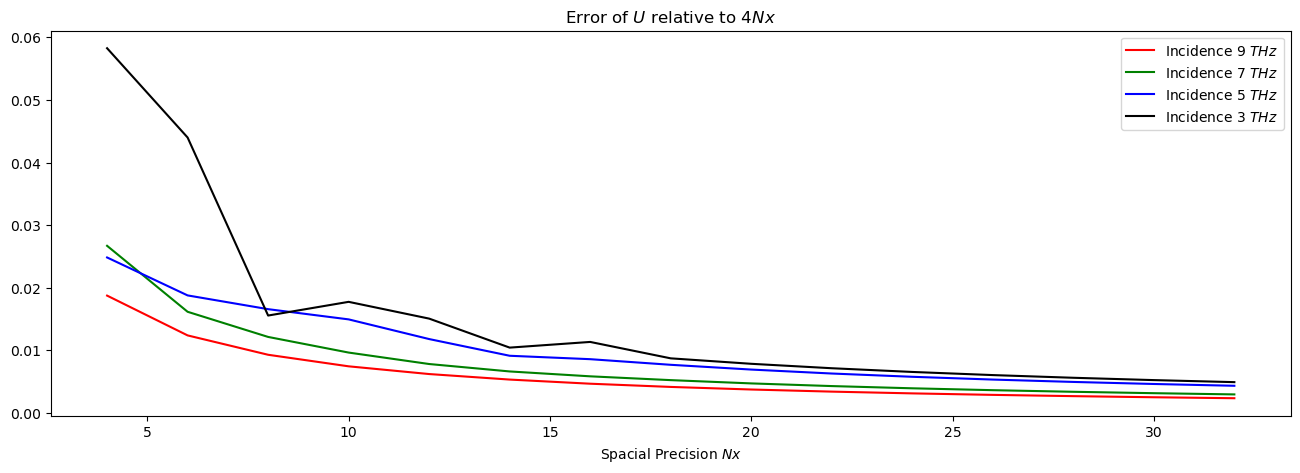

In [6]:
# Convergence Study for Nx
NxList = list(range(4,34,2))
epsilon_u=3; epsilon_w=4; envelope='nsmooth'; d=4; theta=0; L=16; sum='pade';
F = [9,7,5,3]; colors = ['r','g','b','k']; plt.figure(figsize=(16,5))
for idx in range(len(F)):
    f = F[idx]; clr = colors[idx]; error = []
    for Nx in NxList:
        NxLarge = Nx*4;
        error.append(norm(ifft(HOPE(epsilon_u, epsilon_w, envelope, d, theta, f, Nx, L, sum)[0])\
                 -ifft(HOPE(epsilon_u, epsilon_w, envelope, d, theta, f, NxLarge, L, sum)[0])[::4]))
    plt.plot(NxList, error, color=clr, label=r'Incidence {} $THz$'.format(f))
plt.xlabel(r'Spacial Precision $Nx$')
plt.title(r'Error of $U$ relative to $4Nx$')
plt.legend()
plt.savefig('image/Nx.png', dpi=defaultDPI, bbox_inches='tight')
plt.show()

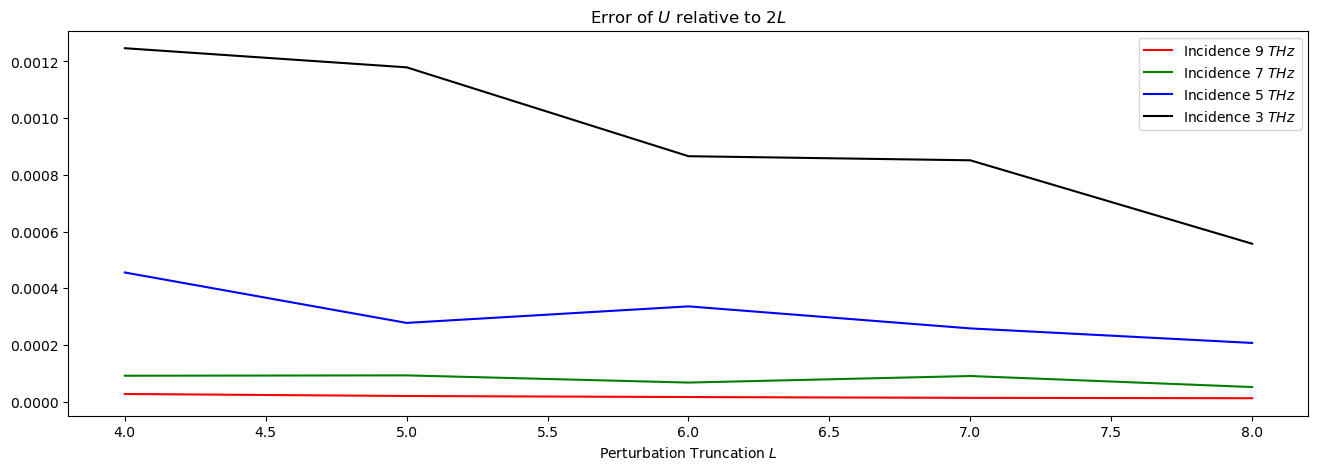

In [7]:
# Convergence Study for L
LList = list(range(4,9)) # L=1,2,3 cause singular matrix
epsilon_u=3; epsilon_w=4; envelope='nsmooth'; d=4; theta=0; Nx=128; sum='pade';
plt.figure(figsize=(16,5))
for idx in range(len(F)):
    f = F[idx]; clr = colors[idx]; error = []
    for L in LList:
        LLarge = L*2;
        error.append(norm(ifft(HOPE(epsilon_u, epsilon_w, envelope, d, theta, f, Nx, L, sum)[0])\
                 -ifft(HOPE(epsilon_u, epsilon_w, envelope, d, theta, f, Nx, LLarge, sum)[0])))
    plt.plot(LList, error, color=clr, label=r'Incidence {} $THz$'.format(f))
plt.xlabel(r'Perturbation Truncation $L$')
plt.title(r'Error of $U$ relative to $2L$')
plt.legend()
plt.savefig('image/L.png', dpi=defaultDPI, bbox_inches='tight')
plt.show()

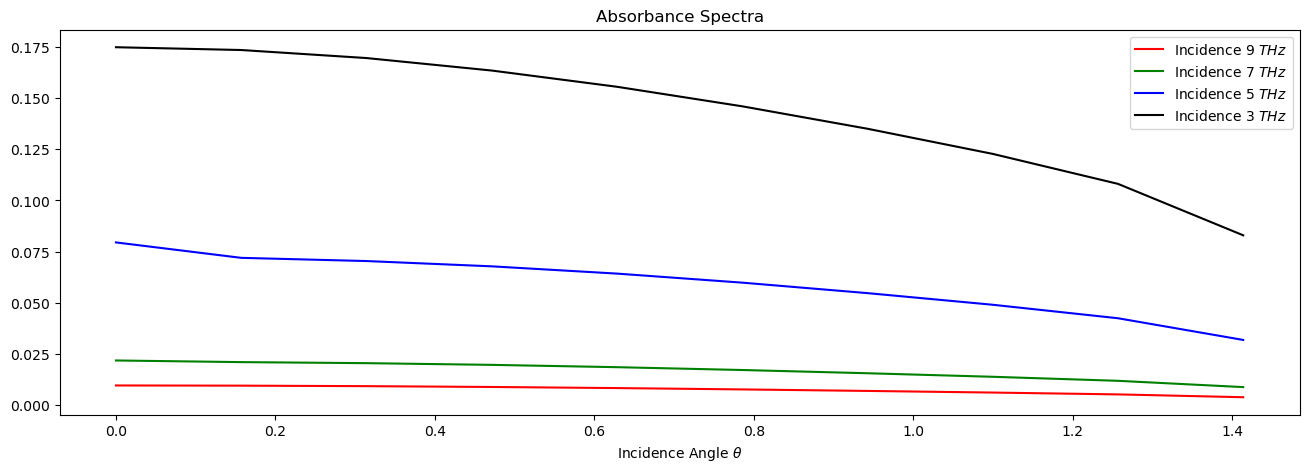

In [8]:
# Performance Study for theta
thetaList = np.linspace(0,np.pi/2,10,endpoint=False) # theta=pi/2 causes singular matrix
epsilon_u=3; epsilon_w=4; envelope='nsmooth'; d=4; L=16; Nx=128; sum='pade';
plt.figure(figsize=(16,5))
for idx in range(len(F)):
    f = F[idx]; clr = colors[idx]; Absorbance = []
    for theta in thetaList:
        Absorbance.append(HOPE(epsilon_u, epsilon_w, envelope, d, theta, f, Nx, L, sum)[2])
    plt.plot(thetaList, Absorbance, color=clr, label=r'Incidence {} $THz$'.format(f))
plt.xlabel(r'Incidence Angle $\theta$')
plt.title('Absorbance Spectra')
plt.legend()
plt.savefig('image/theta.png', dpi=defaultDPI, bbox_inches='tight')
plt.show()

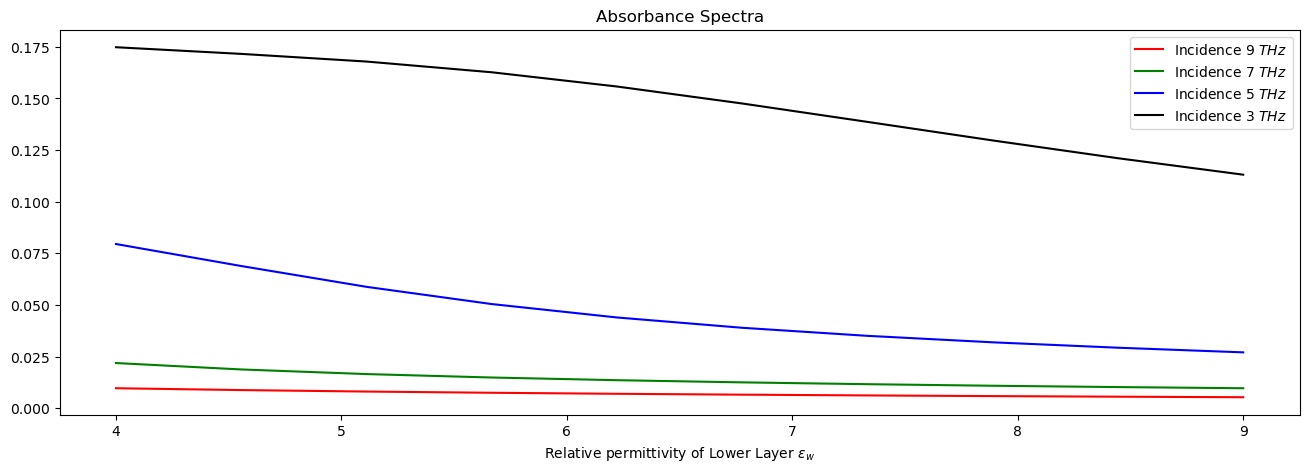

In [9]:
# Performance Study for epsilon_w
wList = np.linspace(4,9,10)
epsilon_u=3; envelope='nsmooth'; d=4; theta=0; L=16; Nx=128; sum='pade';
plt.figure(figsize=(16,5))
for idx in range(len(F)):
    f = F[idx]; clr = colors[idx]; Absorbance = []
    for epsilon_w in wList:
        Absorbance.append(HOPE(epsilon_u, epsilon_w, envelope, d, theta, f, Nx, L, sum)[2])
    plt.plot(wList, Absorbance, color=clr, label=r'Incidence {} $THz$'.format(f))
plt.xlabel(r'Relative permittivity of Lower Layer $\epsilon_w$')
plt.title('Absorbance Spectra')
plt.legend()
plt.savefig('image/w.png', dpi=defaultDPI, bbox_inches='tight')
plt.show()

In [ ]:
# Performance Study for Envelope Functions
F = np.linspace(1,13,Nf)
epsilon_u=3; epsilon_w=4; theta=0; Nx=128; L=16; sum='pade'

plt.figure(figsize=(16,5)); envelope='nsmooth'
for idx in range(len(D)):
    d = D[idx]; Absorbance = []
    for f in F:
        Absorbance.append(HOPE(epsilon_u, epsilon_w, envelope, d, theta, f, Nx, L, sum)[2])
    plt.plot(F, Absorbance, color=colors[idx], label=r'Nonlocal, Period {} $\mu m$'.format(d))
plt.xlabel(r'Incident linear frequency $(THz)$')
plt.title('Absorbance Spectra with Default Setting')
plt.legend()
plt.savefig('image/default.png', dpi=defaultDPI, bbox_inches='tight')
plt.show()

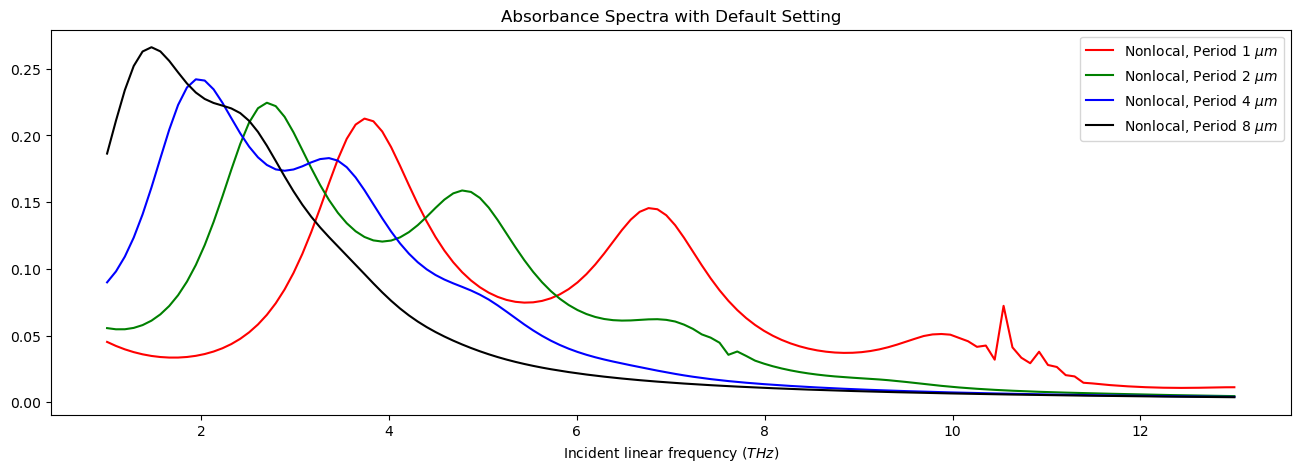

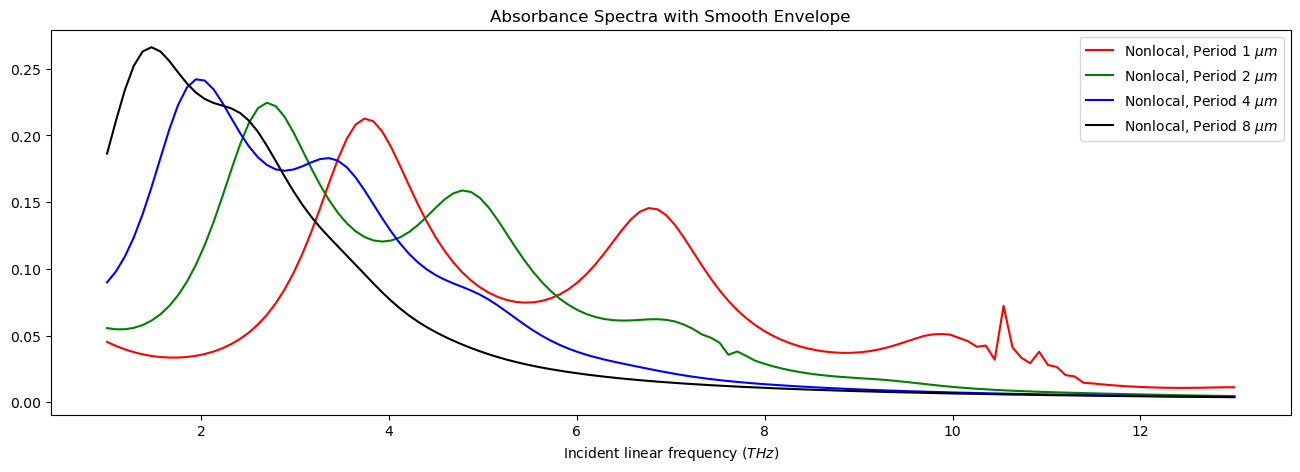

In [10]:
# Performance Study for Envelope Functions

plt.figure(figsize=(16,5))
epsilon_u=3; epsilon_w=4; theta=0; Nx=128; L=16; sum='pade'; envelope='sine'
for idx in range(len(D)):
    d = D[idx]; Absorbance = []
    for f in F:
        Absorbance.append(HOPE(epsilon_u, epsilon_w, envelope, d, theta, f, Nx, L, sum)[2])
    plt.plot(F, Absorbance, color=colors[idx], label=r'Nonlocal, Period {} $\mu m$'.format(d))
plt.xlabel(r'Incident linear frequency $(THz)$')
plt.title('Absorbance Spectra with Smooth Envelope')
plt.legend()
plt.savefig('image/Sine.png', dpi=defaultDPI, bbox_inches='tight')
plt.show()

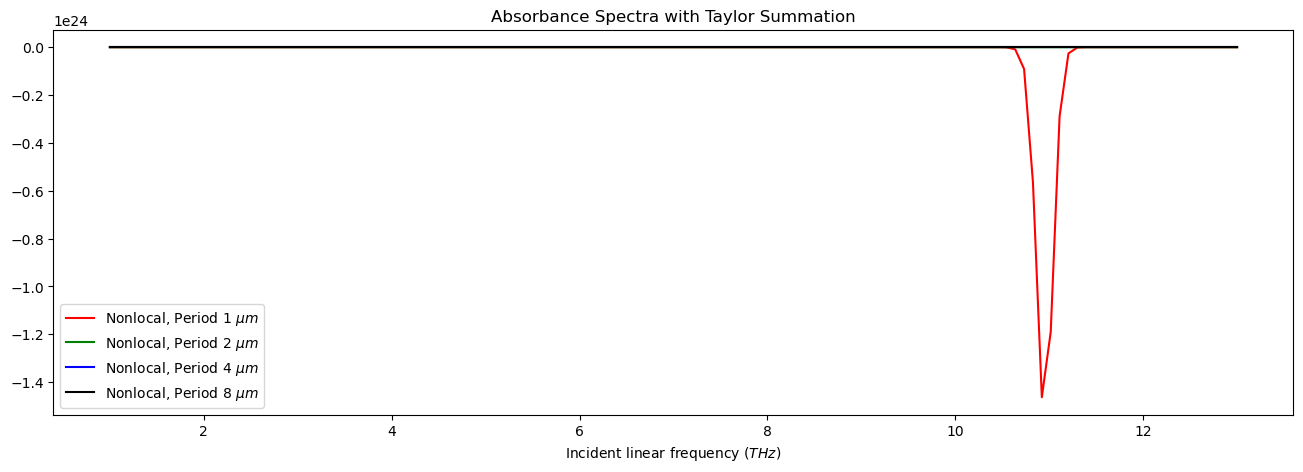

In [11]:
# Performance Study for Summation Algorithms
plt.figure(figsize=(16,5))
epsilon_u=3; epsilon_w=4; envelope='nsmooth'; theta=0; Nx=128; L=16; sum='taylor' 
for idx in range(len(D)):
    d = D[idx]; Absorbance = []
    for f in F:
        Absorbance.append(HOPE(epsilon_u, epsilon_w, envelope, d, theta, f, Nx, L, sum)[2])
    plt.plot(F, Absorbance, color=colors[idx], label=r'Nonlocal, Period {} $\mu m$'.format(d))
plt.xlabel(r'Incident linear frequency $(THz)$')
plt.title('Absorbance Spectra with Taylor Summation')
plt.legend()
plt.savefig('image/Taylor.png', dpi=defaultDPI, bbox_inches='tight')
plt.show()